# Medical Images Project
---

**RadCTTACEomics_1447**

- Reference image: 11_AP_Ax5.00mm

3D Image Segmentation


In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
#from PIL import Image
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from scipy import ndimage as ndi
from skimage.feature import canny,peak_local_max
from skimage.filters import gaussian, sobel
from skimage.segmentation import watershed, mark_boundaries
from skimage.measure import regionprops, label, find_contours
import matplotlib.patches as mpatches
from sklearn.metrics import f1_score, cohen_kappa_score
from skimage.morphology import remove_small_objects, binary_dilation,binary_erosion
import pywt
from matplotlib.colors import BoundaryNorm

In [2]:
gt_liver_mask = np.load('gt_liver_mask.npy')
gt_tumor_mask = np.load('gt_tumor_mask.npy')
ct_images = np.load('windowed_ct_images.npy')
aspect_ratio_coronal=6.213588372139264
aspect_ratio_sagittal=6.213588372139264

**Consider the Tumor mask associated to the reference image, and extract its bounding box and centroid.**  

---
As a result of the findings derived from objective one, it has been established that the tumour mask contains multiple tumours. To facilitate the subsequent tasks, it is necessary to separate them.

In [ ]:
def split_components_3d(mask):
    # Verify that the input is a binary 3D mask
    if mask.ndim != 3:
        raise ValueError('The mask must be three-dimensional (3D).')
    
    if mask.dtype != np.uint8:
        raise ValueError('The mask must be uint8 type')
    
    if not np.all(np.isin(mask, [0, 1])):
        raise ValueError('The mask must contain only 0 and 1 values.')
    
    # label connected components
    # structure=np.ones((3,3,3)) defines 3D connectivity (26-connectivity)
    labels, components_amount = ndi.label(mask, structure=np.ones((3,3,3)))
    
    # Create a separate mask for each component
    individuals_mask = []
    for i in range(1, components_amount + 1):
        mask_componente = np.zeros_like(mask)
        mask_componente[labels == i] = 1
        individuals_mask.append(mask_componente)
    
    print(f'Connected {components_amount} components found')
    return individuals_mask

individuals_mask=split_components_3d(gt_tumor_mask)

Connected 3 components found


In [ ]:
def obtain_3d_bbox(tumor_mask, idx):
    coords = np.argwhere(tumor_mask > 0)
    z_coords, y_coords, x_coords = coords[:, 0], coords[:, 1], coords[:, 2]
    y_min, y_max = np.min(y_coords), np.max(y_coords)
    x_min, x_max = np.min(x_coords), np.max(x_coords)
    z_min, z_max = np.min(z_coords), np.max(z_coords)
    print(f'Mask {idx} Bounding box: z_min {z_min}, y_min {y_min}, x_min {x_min}, z_max {z_max}, y_max {y_max}, x_max {x_max}')
    return (z_min, y_min, x_min, z_max, y_max, x_max)

def show_3d_centroid(tumor_mask, idx):
    coords = np.argwhere(tumor_mask > 0)
    z_coords, y_coords, x_coords = coords[:, 0], coords[:, 1], coords[:, 2]
    centroid = (np.mean(z_coords),np.mean(y_coords), np.mean(x_coords))
    print(f'Mask {idx} Centroid z {centroid[0]}, y {centroid[1]}, x {centroid[2]}')
    return centroid

In [ ]:
bbox=[]
centroids=[]
for i in range(len(individuals_mask)):
    bbox.append(obtain_3d_bbox(individuals_mask[i],i))
    centroids.append(show_3d_centroid(individuals_mask[i],i))
    print('----------------------------------------------------------------------')

Mask 0 Bounding box: z_min 11, y_min 203, x_min 140, z_max 14, y_max 221, x_max 164
Mask 0 Centroid z 12.80070754716981, y 211.6615566037736, x 152.14268867924528
----------------------------------------------------------------------
Mask 1 Bounding box: z_min 18, y_min 106, x_min 243, z_max 23, y_max 132, x_max 264
Mask 1 Centroid z 20.48323793949305, y 120.54619787408014, x 253.04578904333607
----------------------------------------------------------------------
Mask 2 Bounding box: z_min 25, y_min 223, x_min 100, z_max 27, y_max 236, x_max 111
Mask 2 Centroid z 25.804878048780488, y 230.22357723577235, x 105.65447154471545
----------------------------------------------------------------------


**Create a semi-automatic tumor segmentation algorithm that only uses the CT image, and
either the bounding box or the centroid of the tumor.**

---


En esta segmentación se puede usar o los centroides o el bounding box del ground truth, en métodos de detección médica, se prioriza reducir los falsos negativos (aumentar la sensibilidad) porque el riesgo de no detectar una enfermedad y dejar a un paciente sin tratamiento suele ser mucho más grave que el inconveniente de realizar pruebas adicionales a personas sanas debido a falsos positivos. 
Se intento con centroide usando hessian+canny+centroid (tardaba mucho), se ha implementado una versión sin hesisan y usando bbox, demasiado tiempo (centroide), y además el resultado es nulo(ambos), solo Specificity=1, lo demás a 0.  
Watershed es particularmente útil cuando se dispone de una región de interés acotada (bounding box) y un buen mapa de bordes (Canny), ya que puede aprovechar estos para delimitar los contornos del tumor de manera efectiva y rápida

In [ ]:
def segment_bounding_box_3d(arr, bbox, canny_sigma=2.0, min_size=100,  border_dilate_iters=1):
    z_min, y_min, x_min, z_max, y_max, x_max = bbox
    sub = arr[z_min:z_max, y_min:y_max, x_min:x_max]

    # --- 3D 'Canny': combine Canny edges along each axis ---
    # Canny is 2D; run along each axis and combine
    edges = np.zeros_like(sub, dtype=bool)
    # ZY plane (for each X)
    for x in range(sub.shape[2]):
        edges[..., x] |= canny(sub[..., x], sigma=canny_sigma)
    # ZX plane (for each Y)
    for y in range(sub.shape[1]):
        edges[:, y, :] |= canny(sub[:, y, :], sigma=canny_sigma)
    # YX plane (for each Z)
    for z in range(sub.shape[0]):
        edges[z, ...] |= canny(sub[z, ...], sigma=canny_sigma)
    # Now edges is a 3D mask of detected edges

    # --- 3D Gradient (Sobel) for watershed elevation map ---
    elevation_map = np.sqrt(
        sum(np.square(ndi.sobel(sub, axis=i)) for i in range(3))
    )

    # --- Watershed markers: label connected non-edge regions ---
    # Invert edges for marker labeling (watershed grows from non-edges)
    markers, _ = ndi.label(~edges)

    # Optional: Mask for the region (avoid growing into background)
    mask_fg = sub > np.percentile(sub, 22)

    # --- 3D Watershed ---
    seg = watershed(elevation_map, markers, mask=mask_fg)

    # --- Select largest non-background region ---
    region_labels, region_counts = np.unique(seg, return_counts=True)
    if len(region_labels) > 1:
        region_labels = region_labels[1:]  # skip 0 (background)
        region_counts = region_counts[1:]
        largest_region = region_labels[np.argmax(region_counts)]
        mask_sub = seg == largest_region
    else:
        mask_sub = np.zeros_like(sub, dtype=bool)

    # Remove small objects in 3D
    # --- DILATE MASK TO REACH BORDER (OPTIONAL: to ensure region grows up to the edge) ---
    # This step helps reach the full tumoral region up to the detected border.
    # The border is defined as the edge of the region.
    for _ in range(border_dilate_iters):
        mask_sub = binary_dilation(mask_sub)
        # Prevent leaking outside the area surrounded by canny edges
        mask_sub[edges] = False

    # --- Extract border as a separate mask ---
    border_sub = mask_sub ^ binary_erosion(mask_sub)

    # Place the masks back into the full array
    mask = np.zeros_like(arr, dtype=bool)
    border = np.zeros_like(arr, dtype=bool)
    mask[z_min:z_max, y_min:y_max, x_min:x_max] = mask_sub
    border[z_min:z_max, y_min:y_max, x_min:x_max] = border_sub

    return mask, border

In [14]:
# sigma de 2 a 1.5 en tumor 1, bajan milesimas, y los demás estan correctamente
# s a 1 mejora en 0 por milesimas, pero perdida de decimas en el 1
# con sharpening desmejora general de decimas
segmentations=[]
borders=[]
for i in range(len(bbox)):
    segmentation, border=segment_bounding_box_3d(ct_images,bbox[i])
    segmentations.append(segmentation)
    borders.append(border)

Apuntes de los slices con tumor:  
Original 0, [0-3]  
Original 1, [4-9]  
Original 2, [10-12]

segment_bounding_box_3d hessian+canny+watershed
tumor 0, [0-2] 
Original 1, [4-8]
Original 2, [10-12]

---
- 0 Slice 11: 
- 1 Slice 12:
- 2 Slice 13: 
- 3 Slice 14: 
- 4 Slice 18:
- 5 Slice 19:
- 6 Slice 20:
- 7 Slice 21:
- 8 Slice 22:
- 9 Slice 23:
- 10 Slice 25:
- 11 Slice 26:
- 12 Slice 27:

In [15]:

slices=[11,12,13,14,18,19,20,21,22,23,25,26,27]
len(slices)

13

(-0.5, 511.5, 511.5, -0.5)

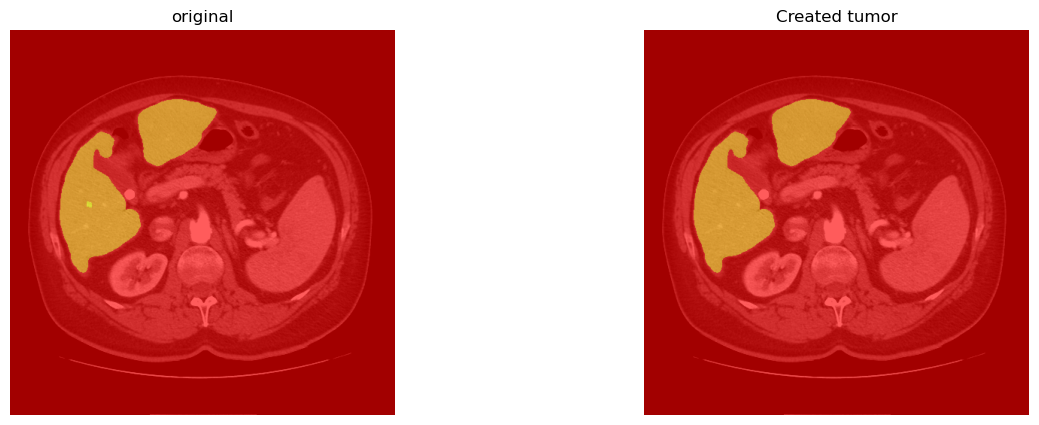

In [ ]:
slice_idx=12
ntumor=2
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(ct_images[slices[slice_idx]], cmap='gray')
axes[0].imshow(individuals_mask[ntumor][slices[slice_idx]], cmap='autumn', alpha=0.4)
axes[0].imshow(gt_liver_mask[slices[slice_idx]], cmap='autumn', alpha=0.4)
axes[0].set_title('original')
axes[0].axis('off')
axes[1].imshow(ct_images[slices[slice_idx]], cmap='gray')
axes[1].imshow(segmentations[ntumor][slices[slice_idx]], cmap='prism', alpha=0.4)  
axes[1].imshow(gt_liver_mask[slices[slice_idx]], cmap='autumn', alpha=0.4)
axes[1].set_title('Created tumor')
axes[1].axis('off')

In [ ]:
def find_tumor_slice(tumor_mask):
    # Find slices where the tumor appears in each plane.
    # Calculate the sum of the mask values in each direction
    z_sums = np.sum(tumor_mask, axis=(1, 2))
    y_sums = np.sum(tumor_mask, axis=(0, 2))
    x_sums = np.sum(tumor_mask, axis=(0, 1))
    
    # Find slices with tumor
    z_tumor_slices = np.where(z_sums > 0)[0]
    y_tumor_slices = np.where(y_sums > 0)[0]
    x_tumor_slices = np.where(x_sums > 0)[0]
    
    if len(z_tumor_slices) == 0 or len(y_tumor_slices) == 0 or len(x_tumor_slices) == 0:
        print('No tumor was found in any of the plans.')
        return  
    
    # Select central slices with tumor
    z_slice = z_tumor_slices[len(z_tumor_slices) // 2]
    y_slice = y_tumor_slices[len(y_tumor_slices) // 2]
    x_slice = x_tumor_slices[len(x_tumor_slices) // 2]    
    return z_slice,y_slice,x_slice

In [ ]:
def visualize_segmentation_multiplanar(images, tumor_mask):
    '''
    Visualizes the CT image with the tumor mask superimposed in axial,
    coronal and sagittal planes. Automatically highlights slices where the tumor appears.
    '''
    z_slice,y_slice,x_slice=find_tumor_slice(tumor_mask)

    # Create a custom color map for the tumor (semi-transparent red).
    colors = [(1, 0, 0, 0), (1, 0, 0, 0.7)]  # Red transparent to semi-opaque red
    tumor_cmap = ListedColormap(colors, name='tumor_cmap')
    
    # Normalize images for display
    def normalize_image(img):
        img_min = np.min(img)
        img_max = np.max(img)
        return (img - img_min) / (img_max - img_min) if img_max > img_min else img
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    plt.suptitle(f'Multiplanar display of detected tumor segmentation', fontsize=16)
    
    # Axial
    ax = axes[0]
    ax.imshow(normalize_image(images[z_slice]), cmap='gray')
    ax.imshow(tumor_mask[z_slice], cmap=tumor_cmap)
    ax.set_title(f'Axial (z={z_slice})', fontsize=14)
    ax.axis('off')
    
    # Coronal 
    ax = axes[1]
    ax.imshow(images[:, y_slice, :], cmap='gray')
    ax.imshow(tumor_mask[:, y_slice, :], cmap=tumor_cmap, aspect=aspect_ratio_coronal)
    ax.set_title(f'Coronal (y={y_slice})', fontsize=14)
    ax.axis('off')
    
    # Sagital
    ax = axes[2]
    ax.imshow(images[:, :, x_slice], cmap='gray')
    ax.imshow(tumor_mask[:, :, x_slice], cmap=tumor_cmap, aspect=aspect_ratio_sagittal)
    ax.set_title(f'Sagital (x={x_slice})', fontsize=14)
    ax.axis('off')  
    plt.show()

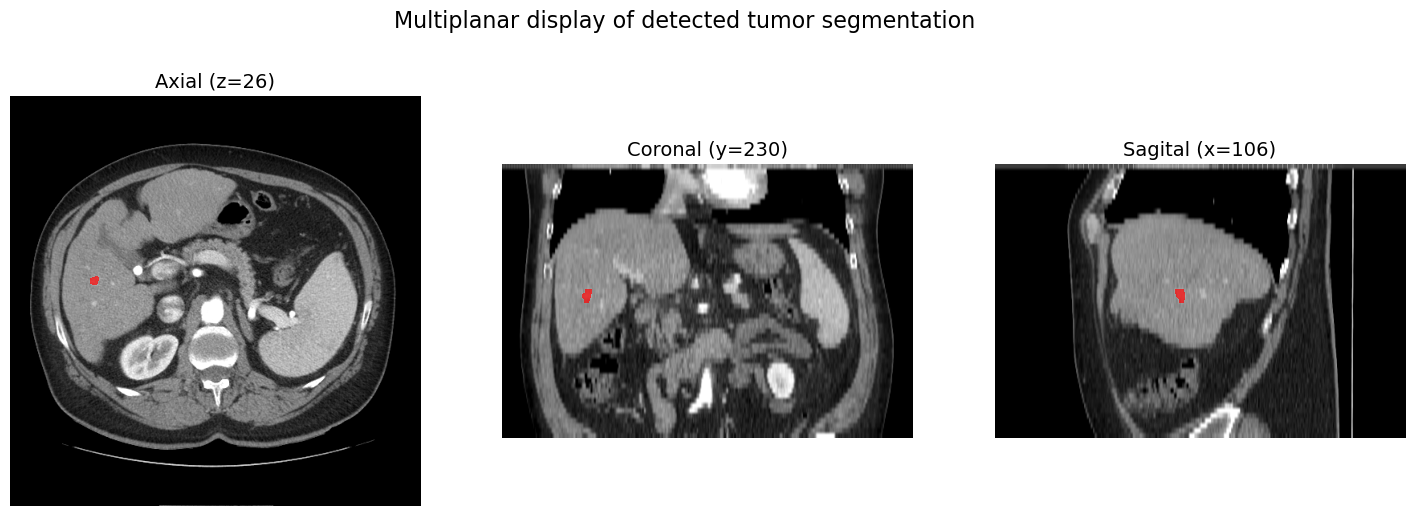

In [44]:
visualize_segmentation_multiplanar(ct_images, individuals_mask[2])

In [ ]:
def visualize_comparison_multiplanar(images, ground_truth, tumor_mask):
    '''
    Visualize the CT image with the ground truth mask and the segmented mask 
    automatically in axial, coronal and sagittal planes.
    '''
    # Search slices where any of the masks appear
    combined_mask = np.logical_or(ground_truth > 0, tumor_mask > 0)    
    z_slice,y_slice,x_slice=find_tumor_slice(combined_mask)
    
    gt_colors = [(0, 0, 0, 0), (0, 1, 0, 0.7)]  # green
    gt_cmap =  ListedColormap(colors, name='gt_cmap')
    
    seg_colors = [(0, 0, 0, 0), (1, 0, 0, 0.7)]  # red 
    seg_cmap =  ListedColormap(colors, name='seg_cmap')
    
    # Normalize images for display
    def normalize_image(img):
        img_min = np.min(img)
        img_max = np.max(img)
        return (img - img_min) / (img_max - img_min) if img_max > img_min else img
    

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    plt.suptitle('Comparison of automatic segmentation and ground truth', fontsize=16)
    
    # Create color coded overlay masks
    # Values: 0=ground, 1=ground truth only, 2=segmentation only, 3=overlay
    def create_overlap_display(gt, seg):
        overlap = np.zeros_like(gt)
        overlap[gt > 0] = 1  # Green (only ground truth)
        overlap[seg > 0] += 2  # Add 2 where there is segmentation
        return overlap

    # Create overlay masks for each plane
    axial_overlap = create_overlap_display(ground_truth[z_slice], tumor_mask[z_slice])
    coronal_overlap = create_overlap_display(ground_truth[:, y_slice, :], tumor_mask[:, y_slice, :])
    sagittal_overlap = create_overlap_display(ground_truth[:, :, x_slice], tumor_mask[:, :, x_slice])
    

    # Create custom colormap for overlay display
    overlap_cmap = plt.cm.colors.ListedColormap(['black', 'green', 'red', 'yellow'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = plt.cm.colors.BoundaryNorm(bounds, overlap_cmap.N)
    
    # Axial 
    mask = axial_overlap > 0
    ax = axes[0]
    ax.imshow(images[z_slice], cmap='gray')
    ax.imshow(np.ma.masked_where(~mask, axial_overlap), cmap=overlap_cmap, norm=norm, alpha=0.7)
    ax.set_title(f'Axial (z={z_slice})', fontsize=14)
    ax.axis('off')
    
    # Plano Coronal
    mask = coronal_overlap > 0
    ax = axes[1]
    ax.imshow(images[:, y_slice, :], cmap='gray')
    ax.imshow(np.ma.masked_where(~mask, coronal_overlap), cmap=overlap_cmap, norm=norm, alpha=0.7, aspect=aspect_ratio_coronal)
    ax.set_title(f'Coronal (y={y_slice})', fontsize=14)
    ax.axis('off')
    
    # Sagittal 
    mask = sagittal_overlap > 0
    ax = axes[2]
    ax.imshow(images[:, :, x_slice], cmap='gray')
    ax.imshow(np.ma.masked_where(~mask, sagittal_overlap), cmap=overlap_cmap, norm=norm, alpha=0.7, aspect=aspect_ratio_sagittal)
    ax.set_title(f'Sagital (x={x_slice})', fontsize=14)
    ax.axis('off')
    
    
    # Add legend
    legend_elements = [
        mpatches.Patch(color='green', label='Ground Truth', alpha=0.7),
        mpatches.Patch(color='red', label='Segmentation', alpha=0.7),
        mpatches.Patch(color='yellow', label='Overlay', alpha=0.7)
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.14)    
    plt.show()

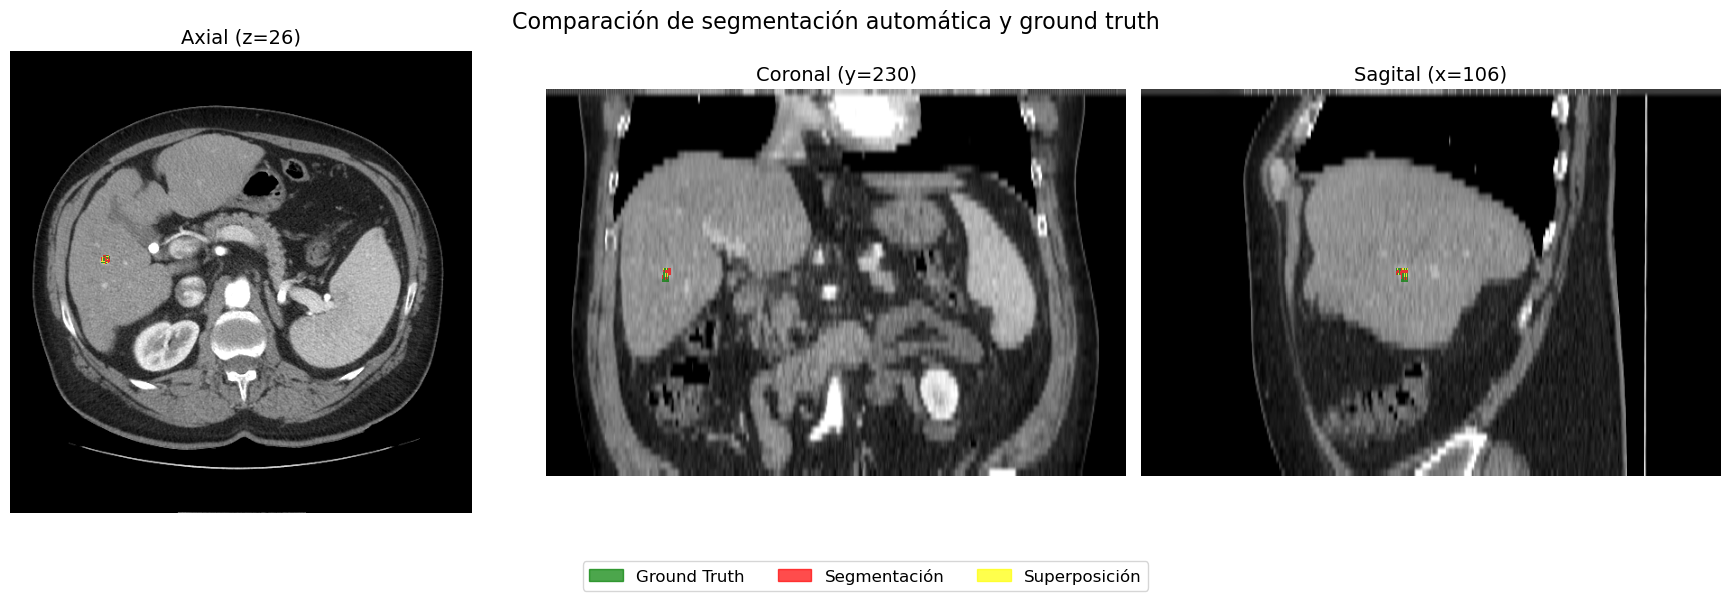

In [32]:
visualize_comparison_multiplanar(ct_images, individuals_mask[2],borders[2])

In [ ]:
def calculate_segmentation_metrics(ground_truth, tumor_mask):

    if tumor_mask.dtype == np.bool_:
        tumor_mask = tumor_mask.astype(int)
    
    # Ensure that they are binary arrays
    ground_truth = ground_truth > 0
    tumor_mask = tumor_mask > 0
    
    # Calculate areas of overlap
    intersection = np.logical_and(ground_truth, tumor_mask)
    union = np.logical_or(ground_truth, tumor_mask)
    
    # Calculate metrics
    true_positive = np.sum(intersection)
    false_positive = np.sum(tumor_mask) - true_positive
    false_negative = np.sum(ground_truth) - true_positive
    # Total number of pixels
    total_pixels = ground_truth.size

    # True Negatives
    true_negative = total_pixels - (true_positive + false_positive + false_negative)
    
    # Metrics
    dice = 2 * true_positive / (2 * true_positive + false_positive + false_negative) if true_positive > 0 else 0
    iou = true_positive / np.sum(union) if np.sum(union) > 0 else 0
    sensitivity_recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
    specificity = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0
    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
    # Coeficiente de Kappa (Cohen's Kappa)
    kappa = cohen_kappa_score(ground_truth.flatten(), tumor_mask.flatten())
    # F1 Score
    f1 = f1_score(ground_truth.flatten(), tumor_mask.flatten())

    return {
        'Dice': dice,
        'IoU': iou,
        'Sensibilidad': sensitivity_recall,
        'Specificity':specificity,
        'Precisión': precision,
        'Cohen's Kappa': kappa,
        'F1 score':f1
    }


Cannot calculate AUC, no prediction probabilities, not just binary masks.
Metrics:
- Dice: Measures the similarity between two sets, 1 matches completely.
- IoU: Degree of overlap between prediction and reference, is the intersection divided by the union of both sets, 1 total total overlap.
- Sensitivity: True positives among the real positives, 1 all real cases are dectected.
- Specificity: True negatives from among the real negatives, 1 dectect all real cases.
- Accuracy: Correct predictions (both positive and negative) out of the total number of cases evaluated, 1 classifies all cases correctly.
- Cohen's Kappa: Better or worse than chance, 1 is perfect agreement, 0 is no better than chance.
- F1 score: Harmonic mean between accuracy and sensitivity, 0 underperforms one of the 2.

In [ ]:
#metrics = calculate_segmentation_metrics(individuals_mask[2],segmentations2[2])
metrics=[]
for i in range(len(individuals_mask)):
    metrics.append(calculate_segmentation_metrics(individuals_mask[i],segmentations[i]))
    print(f'\nTumor {i} segmentation assessment metrics:')
    metrics2=metrics[i]
    for metric, value in metrics2.items():
        print(f'{metric}: {value:.4f}')


Tumor 0 segmentation assessment metrics:
Dice: 0.4317
IoU: 0.2753
Sensibilidad: 0.4139
Specificity: 1.0000
Precisión: 0.4512
Cohen's Kappa: 0.4317
F1 score: 0.4317

Tumor 1 segmentation assessment metrics:
Dice: 0.4287
IoU: 0.2728
Sensibilidad: 0.5127
Specificity: 0.9999
Precisión: 0.3684
Cohen's Kappa: 0.4287
F1 score: 0.4287

Tumor 2 segmentation assessment metrics:
Dice: 0.6247
IoU: 0.4543
Sensibilidad: 0.6057
Specificity: 1.0000
Precisión: 0.6450
Cohen's Kappa: 0.6247
F1 score: 0.6247


In [ ]:
def analyze_hounsfield_regions(images, masks):
    all_hu_values = []

    for img, msk in zip(images, masks):
        region_hu = img[msk == 1]
        all_hu_values.append(region_hu)

    all_hu_values = np.concatenate(all_hu_values)
    #moda
    mean_hu = np.mean(all_hu_values)
    std_hu = np.std(all_hu_values)
    min_hu = np.min(all_hu_values)
    max_hu = np.max(all_hu_values)

    # Show histogram
    plt.figure(figsize=(8, 6))
    plt.hist(all_hu_values, bins=50, color='steelblue', edgecolor='black', alpha=0.75)
    plt.title('Distribution of Hounsfield Unit (HU) Values in Masked Regions')
    plt.xlabel('HU Value')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    print(f'Mean HU: {mean_hu:.2f}')
    print(f'Std Dev HU: {std_hu:.2f}')
    print(f'HU Value Range: [{min_hu:.2f}, {max_hu:.2f}]')

    return {
        'mean': mean_hu,
        'std': std_hu,
        'min': min_hu,
        'max': max_hu,
        'all_hu_values': all_hu_values
    }
#region = windowed_ct_images * liver_mask
results = analyze_hounsfield_regions(windowed_ct_images, liver_mask)

In [ ]:
results = analyze_hounsfield_regions(windowed_ct_images, tumor_mask)

In [ ]:
def analyze_hounsfield_by_slice(image, mask):
    hounsfield_data = []
    for i in range(image.shape[0]):
        
        region_hu = image[i][mask[i] > 0]  # robust for bool or 0/1 mask

        # Handle case with no masked pixels in slice
        if region_hu.size == 0:
            mean_hu = std_hu = min_hu = max_hu = np.nan
        else:
            
            mean_hu = np.mean(region_hu)
            std_hu = np.std(region_hu)
            min_hu = np.min(region_hu)
            max_hu = np.max(region_hu)

        hounsfield_data.append({
            'slice_index': i,
            'mean': mean_hu,
            'std': std_hu,
            'min': min_hu,
            'max': max_hu,
            'hu_values': region_hu
        })
    return hounsfield_data

def show_plot(hounsfield_data, slice_idx):
    all_hu_values = hounsfield_data[slice_idx]['hu_values']
    data_slice=hounsfield_data[slice_idx]
    all_hu_values = np.ravel(all_hu_values)
    plt.figure(figsize=(8, 6))
    if all_hu_values.size > 0:
        plt.hist(all_hu_values, bins=50, color='blue', edgecolor='black', alpha=0.75)
    else:
        plt.text(0.5, 0.5, 'No masked region in this slice.', ha='center', va='center')
    plt.title(f'Distribution of Hounsfield Unit (HU) Values in Masked Regions (Slice {slice_idx})')
    plt.xlabel('HU Value')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    print(f'In the slice {slice_idx}')
    print(f'Mean HU: {data_slice['mean']:.2f}')
    print(f'Std Dev HU: {data_slice['std']:.2f}')
    print(f'HU Value Range min {data_slice['min']:.2f} and max {data_slice['max']:.2f}')

hounsfield_data = analyze_hounsfield_by_slice(windowed_ct_images, tumor_mask)
show_plot(hounsfield_data,20)

In [ ]:
def texture_analysis_wavelet(image, mask, wavelet='db2', level=2):
    '''
    Perform wavelet-based texture analysis, slice by slice.

    For each slice, mask out the region of interest, apply wavelet decomposition,
    and extract statistics (mean, std) from each sub-band.

    Returns:
        List of dicts with features per slice.
    '''
    results = []
    for idx in range(image.shape[0]):
        slice_img = image[idx]
        slice_mask = mask[idx] > 0
        # Mask out non-ROI pixels (set to 0 or np.nan)
        masked_img = np.where(slice_mask, slice_img, 0)
        # Wavelet decomposition
        coeffs = pywt.wavedec2(masked_img, wavelet=wavelet, level=level)
        bands = {}
        # Approximation coefficients (cA)
        cA = coeffs[0]
        bands['cA_mean'] = np.mean(cA)
        bands['cA_std'] = np.std(cA)
        # Detail coefficients (cH, cV, cD) for each level
        for l, (cH, cV, cD) in enumerate(coeffs[1:], 1):
            bands[f'cH{l}_mean'] = np.mean(cH)
            bands[f'cH{l}_std'] = np.std(cH)
            bands[f'cV{l}_mean'] = np.mean(cV)
            bands[f'cV{l}_std'] = np.std(cV)
            bands[f'cD{l}_mean'] = np.mean(cD)
            bands[f'cD{l}_std'] = np.std(cD)
        results.append(bands)
    return results

def plot_wavelet_band_feature(wavelet_features, band='cA_mean', title='Wavelet Feature', ylabel='Value'):
    vals = [f[band] for f in wavelet_features]
    plt.figure(figsize=(10, 4))
    plt.plot(vals, marker='o')
    plt.title(title)
    plt.xlabel('Slice Index')
    plt.ylabel(ylabel)
    plt.show()
    # Wavelet analysis
wavelet_features = texture_analysis_wavelet(windowed_ct_images, liver_mask, wavelet='db2', level=2)
plot_wavelet_band_feature(wavelet_features)


**Visualize both the provided Tumor mask and the segmented Tumor mask on the image.
Assess the correctness of the algorithm, numerically and visually**